In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

customer_features = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-3/customer_features_with_style.parquet')
transactions = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-1/transactions_clean.parquet')

print(f"Customer features shape: {customer_features.shape}")
print(customer_features.columns.tolist())

Customer features shape: (99345, 21)
['customer_id', 'last_purchase_date', 'frequency', 'monetary', 'recency', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'top_category', 'top_product_type', 'avg_price_paid', 'price_band', 'top_season', 'age_group', 'club_member_status', 'fashion_news_frequency', 'style_affinity', 'style_count', 'style_diversity']


In [3]:
# Select the three RFM dimensions for clustering
# We use the raw values not the scores because KMeans works better on continuous data
rfm_cols = ['recency', 'frequency', 'monetary']

rfm_data = customer_features[rfm_cols].copy()

# Check for nulls
print("Nulls before cleaning:")
print(rfm_data.isnull().sum())

# Drop any rows with nulls - should be minimal
rfm_data.dropna(inplace=True)
valid_idx = rfm_data.index
customer_features_clean = customer_features.loc[valid_idx].copy()

# Scale the features - KMeans is distance based so scale matters enormously
# Without scaling, monetary (which can be in hundreds) dominates recency (which is in days)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

print(f"\nScaled RFM matrix shape: {rfm_scaled.shape}")
print(f"Mean after scaling (should be ~0): {rfm_scaled.mean(axis=0).round(3)}")
print(f"Std after scaling (should be ~1): {rfm_scaled.std(axis=0).round(3)}")

Nulls before cleaning:
recency      0
frequency    0
monetary     0
dtype: int64

Scaled RFM matrix shape: (99345, 3)
Mean after scaling (should be ~0): [-0.  0.  0.]
Std after scaling (should be ~1): [1. 1. 1.]


K=2 | Silhouette: 0.6504 | Inertia: 175460
K=3 | Silhouette: 0.5159 | Inertia: 98116
K=4 | Silhouette: 0.5316 | Inertia: 65178
K=5 | Silhouette: 0.5032 | Inertia: 50278
K=6 | Silhouette: 0.4731 | Inertia: 39712
K=7 | Silhouette: 0.4676 | Inertia: 32628
K=8 | Silhouette: 0.4591 | Inertia: 27807


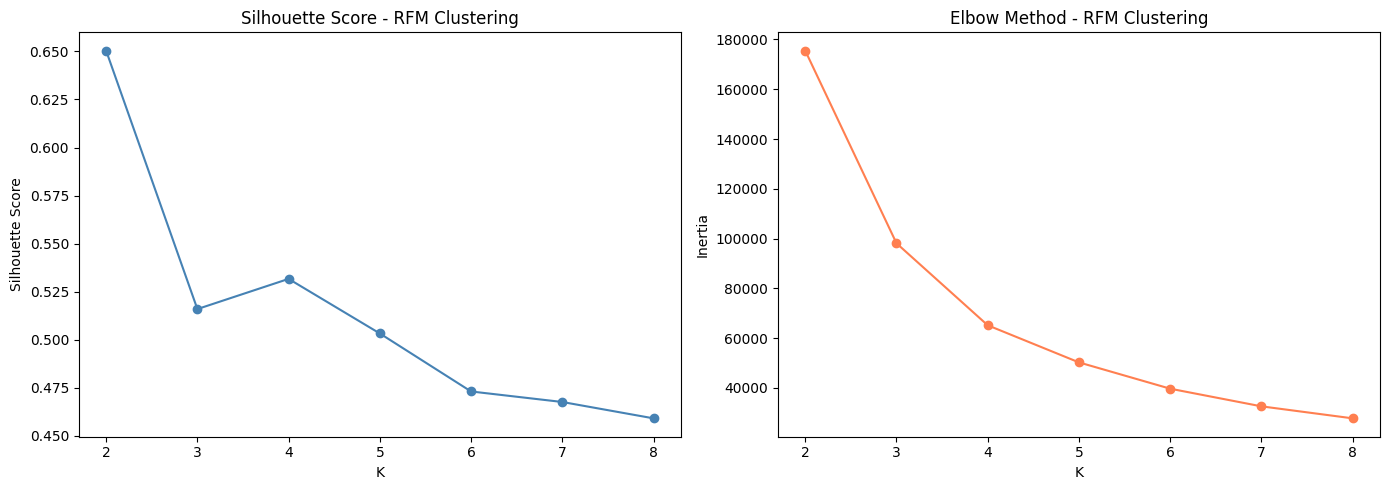

In [4]:
sil_scores = {}
inertias = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, labels, sample_size=5000, random_state=42)
    inertias[k] = km.inertia_
    print(f"K={k} | Silhouette: {sil_scores[k]:.4f} | Inertia: {inertias[k]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(sil_scores.keys()), list(sil_scores.values()), 'o-', color='steelblue')
axes[0].set_title('Silhouette Score - RFM Clustering')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Silhouette Score')

axes[1].plot(list(inertias.keys()), list(inertias.values()), 'o-', color='coral')
axes[1].set_title('Elbow Method - RFM Clustering')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Inertia')

plt.tight_layout()
plt.savefig('/kaggle/working/rfm_cluster_selection.png', dpi=150)
plt.show()

In [5]:
FINAL_K = 4

kmeans_rfm = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
customer_features_clean['rfm_cluster'] = kmeans_rfm.fit_predict(rfm_scaled)

# Look at the centroid values to understand what each cluster represents
centroids = scaler.inverse_transform(kmeans_rfm.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=rfm_cols)
centroid_df.index.name = 'cluster'
print("Cluster Centroids (original scale):")
print(centroid_df.round(2))

Cluster Centroids (original scale):
         recency  frequency  monetary
cluster                              
0         532.11       6.13      0.16
1         118.60      14.89      0.39
2          56.20      79.58      2.24
3          30.42     224.98      7.01


In [6]:
# Look at each cluster's average RFM to assign labels
cluster_summary = customer_features_clean.groupby('rfm_cluster').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    customer_count=('customer_id', 'count')
).round(2)

print(cluster_summary)
print()

# Based on the summary above, assign labels manually
# Low recency + high frequency + high monetary = Champions
# Medium recency + medium frequency = Potential Loyalists  
# High recency + previously decent frequency = At Risk
# High recency + low frequency + low monetary = Lost

# Sort by avg_recency to help identify which is which
print(cluster_summary.sort_values('avg_recency'))

             avg_recency  avg_frequency  avg_monetary  customer_count
rfm_cluster                                                          
0                 532.18           6.13          0.16           30181
1                 118.66          14.87          0.39           55861
2                  56.22          79.51          2.24           11765
3                  30.44         224.77          7.01            1538

             avg_recency  avg_frequency  avg_monetary  customer_count
rfm_cluster                                                          
3                  30.44         224.77          7.01            1538
2                  56.22          79.51          2.24           11765
1                 118.66          14.87          0.39           55861
0                 532.18           6.13          0.16           30181


In [7]:
# Adjust these numbers based on your centroid output above
# The key is: lowest avg_recency = Champions, highest avg_recency + low F/M = Lost

cluster_label_map = {}

sorted_by_recency = cluster_summary.sort_values('avg_recency')
ids_by_recency = sorted_by_recency.index.tolist()

# Lowest recency = most recent = Champions
cluster_label_map[ids_by_recency[0]] = 'Champions'
# Second lowest recency with decent frequency = Potential Loyalists
cluster_label_map[ids_by_recency[1]] = 'Potential Loyalists'
# Third = At Risk
cluster_label_map[ids_by_recency[2]] = 'At Risk'
# Highest recency = Lost
cluster_label_map[ids_by_recency[3]] = 'Lost'

customer_features_clean['segment'] = customer_features_clean['rfm_cluster'].map(cluster_label_map)

print(customer_features_clean['segment'].value_counts())

segment
At Risk                55861
Lost                   30181
Potential Loyalists    11765
Champions               1538
Name: count, dtype: int64


In [9]:
# Compound label - combines WHO they are (RFM) with WHAT they buy (style)
customer_features_clean['compound_segment'] = (
    customer_features_clean['segment'] + ' | ' + 
    customer_features_clean['style_affinity'].fillna('Unknown Style')
)

# Most important compound segments - At Risk customers by style group
at_risk = customer_features_clean[customer_features_clean['segment'] == 'At Risk']
print("At Risk customers by style affinity:")
print(at_risk['style_affinity'].value_counts())
print(f"\nTotal At Risk customers: {len(at_risk)}")
print(f"Total At Risk monetary value: £{at_risk['monetary'].sum():,.2f}")

At Risk customers by style affinity:
style_affinity
Basic Tops & Innerwear      11572
Swimwear & Lingerie         10224
Blouses & Fashion Tops       6918
Trousers & Bottom Wear       6815
Dresses & Full Body Wear     5572
Denim & Bottoms              4376
Knitwear & Sweaters          3782
Accessories & Bags           1956
Jackets & Outerwear          1651
Sweatshirts & Hoodies        1283
Skirts & Lower Body Wear      970
Footwear                      742
Name: count, dtype: int64

Total At Risk customers: 55861
Total At Risk monetary value: £21,820.61


In [10]:
segment_profile = customer_features_clean.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

segment_profile['pct_of_customers'] = (
    segment_profile['customer_count'] / segment_profile['customer_count'].sum() * 100
).round(1)

segment_profile['pct_of_revenue'] = (
    segment_profile['total_revenue'] / segment_profile['total_revenue'].sum() * 100
).round(1)

print(segment_profile.to_string())

                     customer_count  avg_recency_days  avg_frequency  avg_monetary  avg_order_value  total_revenue  pct_of_customers  pct_of_revenue
segment                                                                                                                                             
At Risk                       55861            118.66          14.87          0.39             0.03       21820.61              56.2            34.2
Champions                      1538             30.44         224.77          7.01             0.03       10774.90               1.5            16.9
Lost                          30181            532.18           6.13          0.16             0.03        4968.56              30.4             7.8
Potential Loyalists           11765             56.22          79.51          2.24             0.03       26302.67              11.8            41.2


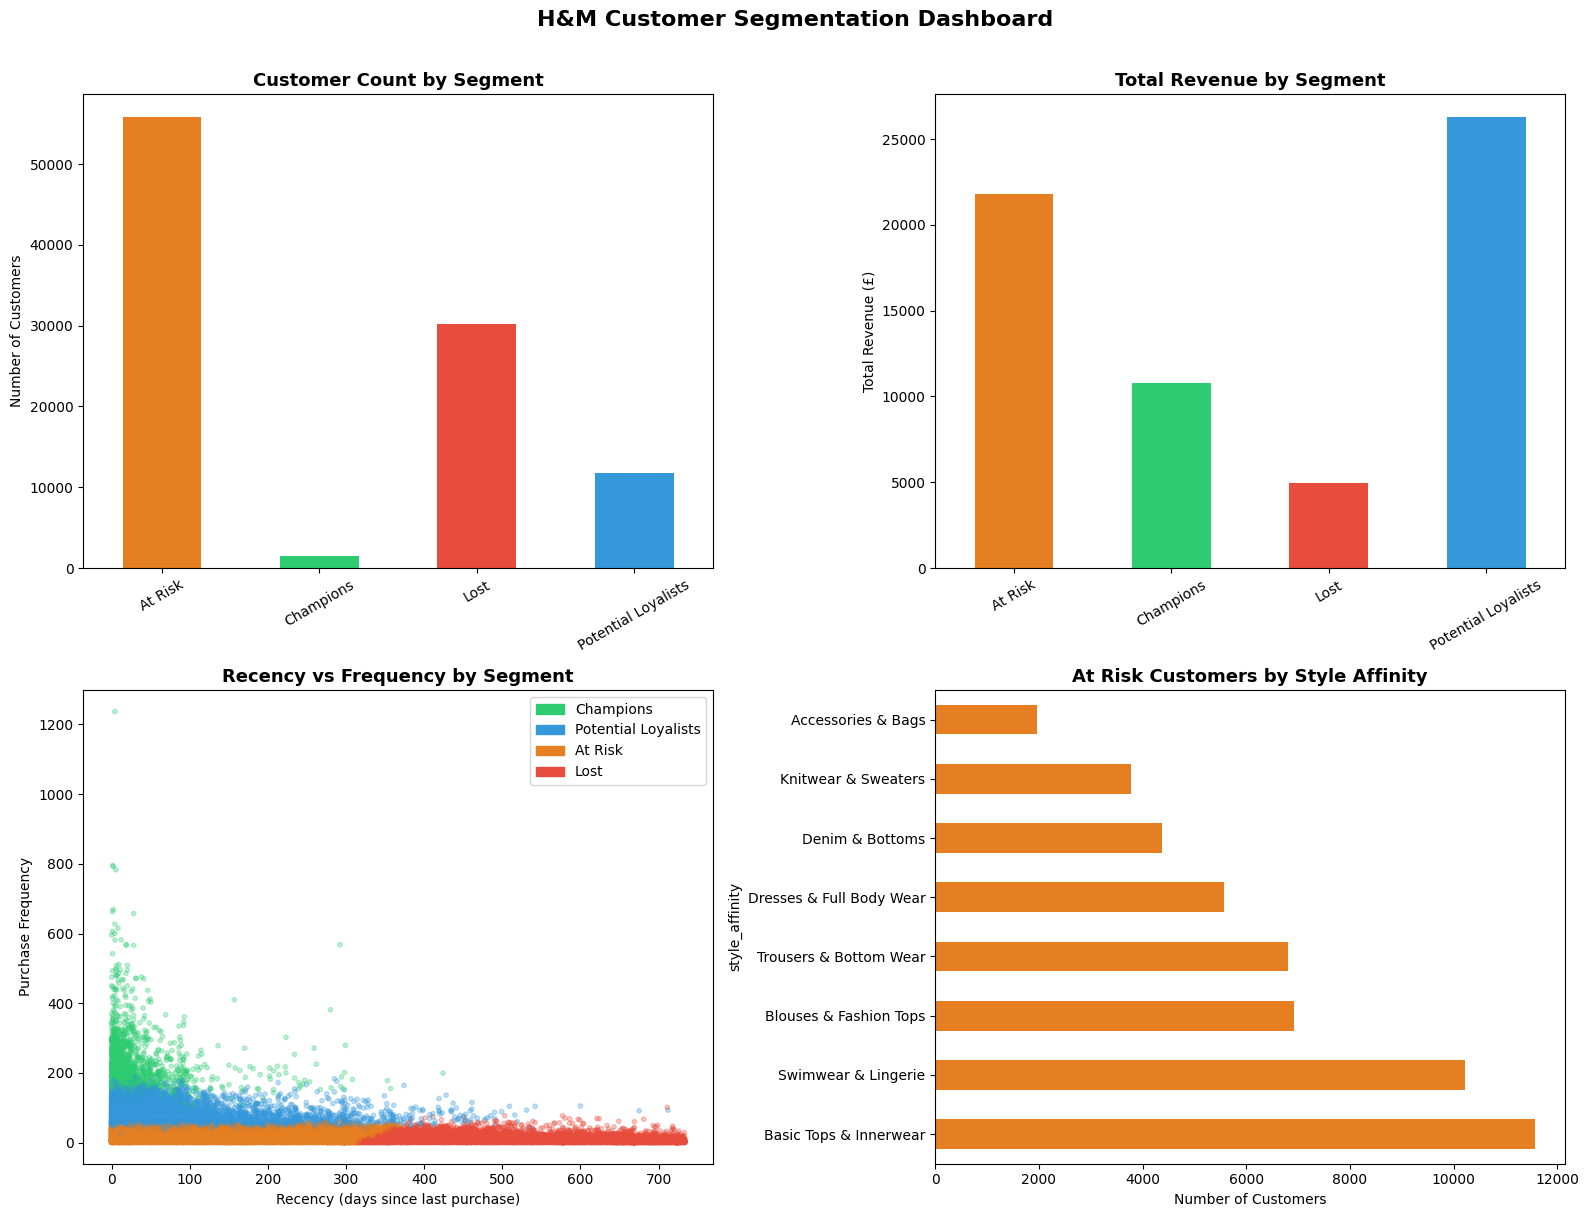

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {
    'Champions': '#2ecc71',
    'Potential Loyalists': '#3498db', 
    'At Risk': '#e67e22',
    'Lost': '#e74c3c'
}
color_list = [colors[s] for s in segment_profile.index]

# Chart 1 - Customer count per segment
segment_profile['customer_count'].plot(kind='bar', ax=axes[0,0], color=color_list)
axes[0,0].set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2 - Revenue per segment
segment_profile['total_revenue'].plot(kind='bar', ax=axes[0,1], color=color_list)
axes[0,1].set_title('Total Revenue by Segment', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Total Revenue (£)')
axes[0,1].tick_params(axis='x', rotation=30)

# Chart 3 - RFM scatter: Recency vs Frequency, colored by segment
segment_colors = customer_features_clean['segment'].map(colors)
axes[1,0].scatter(
    customer_features_clean['recency'],
    customer_features_clean['frequency'],
    c=segment_colors,
    alpha=0.3,
    s=10
)
axes[1,0].set_title('Recency vs Frequency by Segment', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Recency (days since last purchase)')
axes[1,0].set_ylabel('Purchase Frequency')
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
axes[1,0].legend(handles=patches, loc='upper right')

# Chart 4 - Style affinity within At Risk segment
at_risk_style = at_risk['style_affinity'].value_counts().head(8)
at_risk_style.plot(kind='barh', ax=axes[1,1], color='#e67e22')
axes[1,1].set_title('At Risk Customers by Style Affinity', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Customers')

plt.suptitle('H&M Customer Segmentation Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/segmentation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
at_risk_profile = at_risk.groupby('style_affinity').agg(
    customer_count=('customer_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    total_recoverable_revenue=('monetary', 'sum')
).round(2).sort_values('customer_count', ascending=False)

at_risk_profile['pct_of_at_risk'] = (
    at_risk_profile['customer_count'] / at_risk_profile['customer_count'].sum() * 100
).round(1)

print("AT RISK COHORT DEEP DIVE")
print("=" * 60)
print(at_risk_profile.to_string())
print(f"\nTotal recoverable revenue if At Risk reactivated: £{at_risk['monetary'].sum():,.2f}")
print(f"Average order value for At Risk: £{at_risk['avg_order_value'].mean():.2f}")

AT RISK COHORT DEEP DIVE
                          customer_count  avg_recency_days  avg_monetary  avg_order_value  total_recoverable_revenue  pct_of_at_risk
style_affinity                                                                                                                      
Basic Tops & Innerwear             11572            110.34          0.45             0.02                    5185.35            20.7
Swimwear & Lingerie                10224            105.95          0.40             0.03                    4064.93            18.3
Blouses & Fashion Tops              6918            114.42          0.42             0.02                    2901.77            12.4
Trousers & Bottom Wear              6815            119.40          0.36             0.03                    2447.26            12.2
Dresses & Full Body Wear            5572            115.25          0.41             0.03                    2308.50            10.0
Denim & Bottoms                     4376    

In [13]:
customer_features_clean.to_parquet('/kaggle/working/customer_segments.parquet', index=False)

at_risk.to_parquet('/kaggle/working/at_risk_cohort.parquet', index=False)

print("Saved customer_segments.parquet")
print(f"Shape: {customer_features_clean.shape}")
print(f"\nSegment distribution:")
print(customer_features_clean['segment'].value_counts())
print(f"\nSaved at_risk_cohort.parquet")
print(f"At Risk customers: {len(at_risk)}")

Saved customer_segments.parquet
Shape: (99345, 24)

Segment distribution:
segment
At Risk                55861
Lost                   30181
Potential Loyalists    11765
Champions               1538
Name: count, dtype: int64

Saved at_risk_cohort.parquet
At Risk customers: 55861
